In [2]:
import pandas as pd
import numpy as np
np.random.seed(0)
n = 50
df = pd.DataFrame({
    "Customer_ID": np.random.randint(1000, 1100, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Age": np.random.randint(18, 60, n),
    "City": np.random.choice(["Chennai", "Bangalore", "Mumbai", "Delhi"], n),
    "Product": np.random.choice(["Laptop", "Phone", "Tablet", "Headphones"], n),
    "Price": np.random.randint(500, 1000, n),
    "Quantity": np.random.randint(1, 5, n),
    "Purchase_Date": pd.date_range(start="2024-01-01", periods=n, freq="D")
})

# Add missing values
df.loc[5, "Age"] = np.nan
df.loc[10, "Price"] = np.nan

# Add outlier
df.loc[20, "Price"] = 10000

print(df.head())

   Customer_ID  Gender   Age     City Product  Price  Quantity Purchase_Date
0         1044    Male  30.0    Delhi  Laptop  986.0         2    2024-01-01
1         1047  Female  54.0  Chennai   Phone  791.0         2    2024-01-02
2         1064    Male  58.0  Chennai   Phone  714.0         2    2024-01-03
3         1067  Female  32.0   Mumbai  Tablet  689.0         1    2024-01-04
4         1067    Male  33.0  Chennai   Phone  697.0         3    2024-01-05


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Customer_ID    50 non-null     int32         
 1   Gender         50 non-null     object        
 2   Age            49 non-null     float64       
 3   City           50 non-null     object        
 4   Product        50 non-null     object        
 5   Price          49 non-null     float64       
 6   Quantity       50 non-null     int32         
 7   Purchase_Date  50 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int32(2), object(3)
memory usage: 2.9+ KB


Level 1: BASIC ELPLORATION

In [5]:
df.head(5)

,Customer_ID,Gender,Age,City,Product,Price,Quantity,Purchase_Date
0,1044,Male,30.0,Delhi,Laptop,986.0,2,2024-01-01
1,1047,Female,54.0,Chennai,Phone,791.0,2,2024-01-02
2,1064,Male,58.0,Chennai,Phone,714.0,2,2024-01-03
3,1067,Female,32.0,Mumbai,Tablet,689.0,1,2024-01-04
4,1067,Male,33.0,Chennai,Phone,697.0,3,2024-01-05


In [6]:
df.describe()

,Customer_ID,Age,Price,Quantity,Purchase_Date
count,50.000000,49.000000,49.000000,50.000000,50
mean,1052.440000,38.816327,937.673469,2.180000,2024-01-25 12:00:00
min,1009.000000,18.000000,511.000000,1.000000,2024-01-01 00:00:00
25%,1031.250000,28.000000,648.000000,1.000000,2024-01-13 06:00:00
50%,1053.000000,39.000000,758.000000,2.000000,2024-01-25 12:00:00
75%,1076.250000,52.000000,893.000000,3.000000,2024-02-06 18:00:00
max,1099.000000,59.000000,10000.000000,4.000000,2024-02-19 00:00:00
std,26.599187,13.445373,1329.222884,1.023998,NaN


In [7]:
# Entire DataFrame (per column)
df.isna().sum()

Customer_ID      0
Gender           0
Age              1
City             0
Product          0
Price            1
Quantity         0
Purchase_Date    0
dtype: int64

In [8]:
# Find unique values in City and Product
df['City'].unique()
df['Product'].unique()

array(['Laptop', 'Phone', 'Tablet', 'Headphones'], dtype=object)

In [9]:
df[['City', 'Product']].drop_duplicates()

,City,Product
0,Delhi,Laptop
1,Chennai,Phone
3,Mumbai,Tablet
5,Mumbai,Laptop
7,Mumbai,Phone
9,Delhi,Phone
11,Chennai,Headphones
13,Bangalore,Laptop
15,Chennai,Laptop
16,Bangalore,Headphones


In [10]:
# Count number of males and females
df['Gender'].value_counts()

Gender
Male      26
Female    24
Name: count, dtype: int64

In [12]:
# Count only 'Male' entries
male_count = (df['Gender'] == 'Male').sum()

# Count only 'Female' entries
female_count = (df['Gender'] == 'Female').sum()

Level 2: DATA CLEANING

In [14]:
df['Age'].fillna(df['Age'].median(),inplace=True) # age cannot be a mean because some time it provide float values 
df['Price'].fillna(df['Price'].mean(),inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8580\2820014106.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True) # age cannot be a mean because some time it provide float values
C:\Users\Admin\AppData\Local\Temp\ipykernel_8580\2820014106.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object o

DETECT OUTLIERS 

In [15]:
# Detect the outlier in Price ()
df['Price'].describe()

count       50.000000
mean       937.673469
std       1315.589468
min        511.000000
25%        648.750000
50%        758.500000
75%        893.750000
max      10000.000000
Name: Price, dtype: float64

<Axes: >

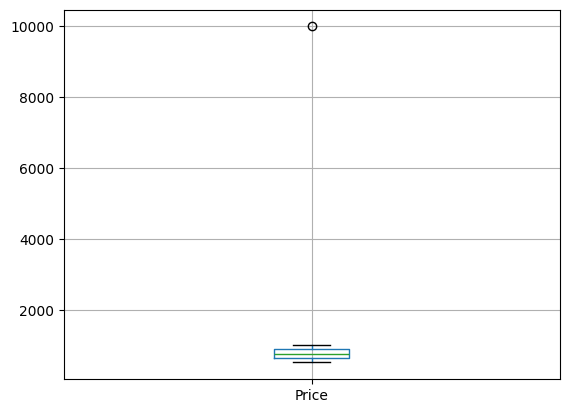

In [16]:
df.boxplot(column='Price')

In [17]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]
print(outliers)

    Customer_ID  Gender   Age    City Product    Price  Quantity Purchase_Date
20         1081  Female  52.0  Mumbai   Phone  10000.0         3    2024-01-21


In [18]:
# Replace outlier with IQR
median = df['Price'].median()
df.loc[(df['Price'] < lower) | (df['Price'] > upper), 'Price'] = median

In [20]:
# Convert Purchase_Date to datetime
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], format='%Y-%m-%d')

Level 3: Feature Engineering

In [21]:
# Create new column → Total_Amount = Price * Quantity
df['Total'] = df['Price'] * df['Quantity']

In [23]:
# Create Age groups (18–25, 26–35, 36–50, 50+)
bins = [18, 25, 35, 50, float('inf')]
labels = ['18-25', '26-35', '36-50', '50+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
#df['Age_Group']

In [22]:
# Extract month from Purchase_Date
df['Month'] = df['Purchase_Date'].dt.month

In [24]:
# Create column High_Value (1 if Total > 2000 else 0)
df['High_Value'] = (df['Total'] > 2000).astype(int)

In [25]:
df[['Age', 'Age_Group', 'Purchase_Date', 'Month', 'Total', 'High_Value']].head()

,Age,Age_Group,Purchase_Date,Month,Total,High_Value
0,30.0,26-35,2024-01-01,1,1972.0,0
1,54.0,50+,2024-01-02,1,1582.0,0
2,58.0,50+,2024-01-03,1,1428.0,0
3,32.0,26-35,2024-01-04,1,689.0,0
4,33.0,26-35,2024-01-05,1,2091.0,1


LEVEL 3: FILTERING AND SORTING

In [26]:
# df['Age'] > 30 → creates a boolean condition
# df[...] → filters rows where condition is True
# Get customers with Age > 30
Age_30 = df[df['Age'] > 30]
#Find transactions where Total_Amount > 3000
transaction_3000 = df[df['Total'] > 3000]

In [27]:
df[df['Age'] > 30][['Customer_ID', 'Age', 'Total']]

,Customer_ID,Age,Total
1,1047,54.0,1582.000000
2,1064,58.0,1428.000000
3,1067,32.0,689.000000
4,1067,33.0,2091.000000
5,1009,39.0,2145.000000
6,1083,53.0,543.000000
7,1021,41.0,1064.000000
8,1036,33.0,1022.000000
9,1087,31.0,604.000000
10,1070,39.0,3750.693878


In [28]:
# To count how many coustomer
df[df['Age'] > 30].shape[0]

35

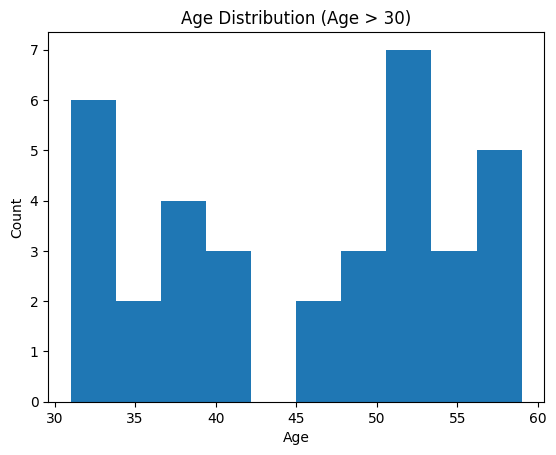

In [29]:
import matplotlib.pyplot as plt

df_age_above_30 = df[df['Age'] > 30]

plt.figure()
plt.hist(df_age_above_30['Age'])
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution (Age > 30)')
plt.show()

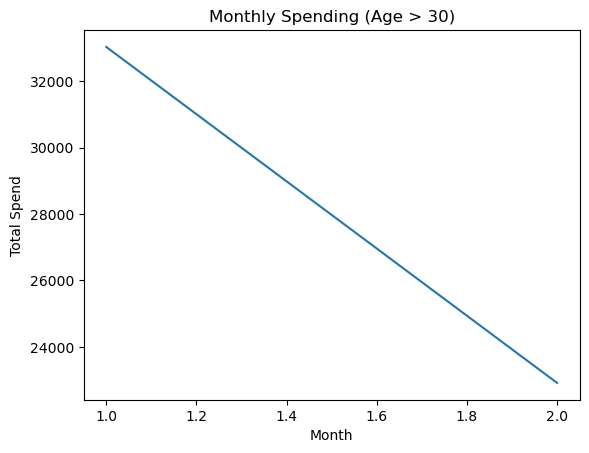

In [ ]:
monthly = df_age_above_30.groupby('Month')['Total'].sum()

plt.figure()
monthly.plot()
plt.title('Monthly Spending (Age > 30)')
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.show()

Level 5: GROUPBY

In [30]:
# Total sales per Product
total_sale = df.groupby('Product')['Total'].sum()
print(total_sale)

Product
Headphones    18736.000000
Laptop        23394.000000
Phone         27684.193878
Tablet        14609.000000
Name: Total, dtype: float64


In [31]:
# Average spending per City
Avg_spending_city = df.groupby('City')['Total'].mean()
print(Avg_spending_city)

City
Bangalore    2033.375000
Chennai      1785.983888
Delhi        1629.090909
Mumbai       1358.541667
Name: Total, dtype: float64


In [32]:
# Total quantity sold per Product
total_quantity = df.groupby('Product')['Quantity'].sum()
print(total_quantity)

Product
Headphones    27
Laptop        28
Phone         35
Tablet        19
Name: Quantity, dtype: int32


In [33]:
# Gender-wise average spending
avg_spending = df.groupby('Gender')['Total'].mean()
print(avg_spending)

Gender
Female    1578.383078
Male      1790.076923
Name: Total, dtype: float64


In [34]:
# for more insight
df.groupby('Gender')['Total'].agg(['mean', 'median', 'sum', 'count'])

,mean,median,sum,count
Gender,,,,
Female,1578.383078,1476.0,37881.193878,24
Male,1790.076923,1828.0,46542.000000,26


In [35]:
# Which City has highest revenue?
high_revenue = df.groupby('City')['Total'].sum().sort_values(ascending=False)
print(high_revenue)

City
Chennai      33933.693878
Delhi        17920.000000
Mumbai       16302.500000
Bangalore    16267.000000
Name: Total, dtype: float64


In [37]:
''' sum → total revenue
mean → avg spending per customer
count → number of transactions '''
df.groupby('City')['Total'].agg(['sum', 'mean', 'count'])

,sum,mean,count
City,,,
Bangalore,16267.000000,2033.375000,8
Chennai,33933.693878,1785.983888,19
Delhi,17920.000000,1629.090909,11
Mumbai,16302.500000,1358.541667,12


Level 6: ADVANCE ANALYSIS

In [38]:
# Find top 5 customers by total spending
top_5 = df.groupby('Customer_ID')['Total'].sum().sort_values(ascending=False).head(5)
print(top_5)

Customer_ID
1019    5954.0
1009    5313.0
1088    4370.0
1012    3964.0
1039    3836.0
Name: Total, dtype: float64


In [39]:
#Find most popular product (by quantity)
df.groupby('Product')['Quantity'].sum().idxmax()

'Phone'

In [41]:
#Calculate daily sales trend
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])
daily_sales = df.groupby('Purchase_Date')['Total'].sum().sort_index()
print(daily_sales)

Purchase_Date
2024-01-01    1972.000000
2024-01-02    1582.000000
2024-01-03    1428.000000
2024-01-04     689.000000
2024-01-05    2091.000000
2024-01-06    2145.000000
2024-01-07     543.000000
2024-01-08    1064.000000
2024-01-09    1022.000000
2024-01-10     604.000000
2024-01-11    3750.693878
2024-01-12     638.000000
2024-01-13     682.000000
2024-01-14    3964.000000
2024-01-15    2763.000000
2024-01-16    1250.000000
2024-01-17    1968.000000
2024-01-18    1222.000000
2024-01-19    2964.000000
2024-01-20     758.000000
2024-01-21    2275.500000
2024-01-22     967.000000
2024-01-23    1434.000000
2024-01-24    1302.000000
2024-01-25    1618.000000
2024-01-26     807.000000
2024-01-27    2696.000000
2024-01-28     648.000000
2024-01-29    3748.000000
2024-01-30     529.000000
2024-01-31     567.000000
2024-02-01     535.000000
2024-02-02     795.000000
2024-02-03    1786.000000
2024-02-04    2292.000000
2024-02-05    3188.000000
2024-02-06     907.000000
2024-02-07    3548.00000

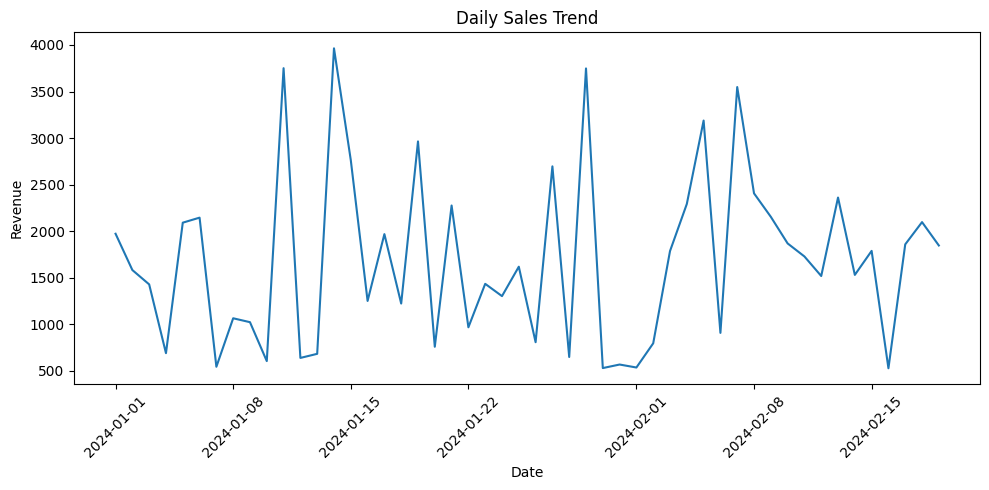

In [42]:
import matplotlib.pyplot as plt
# Ensure datetime
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])
# Daily sales
daily_sales = df.resample('D', on='Purchase_Date')['Total'].sum()
# Plot
plt.figure(figsize=(10,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

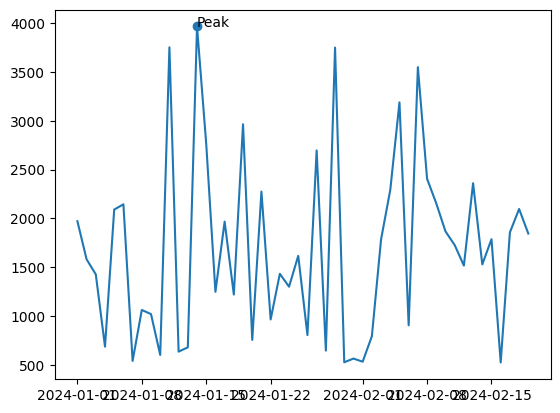

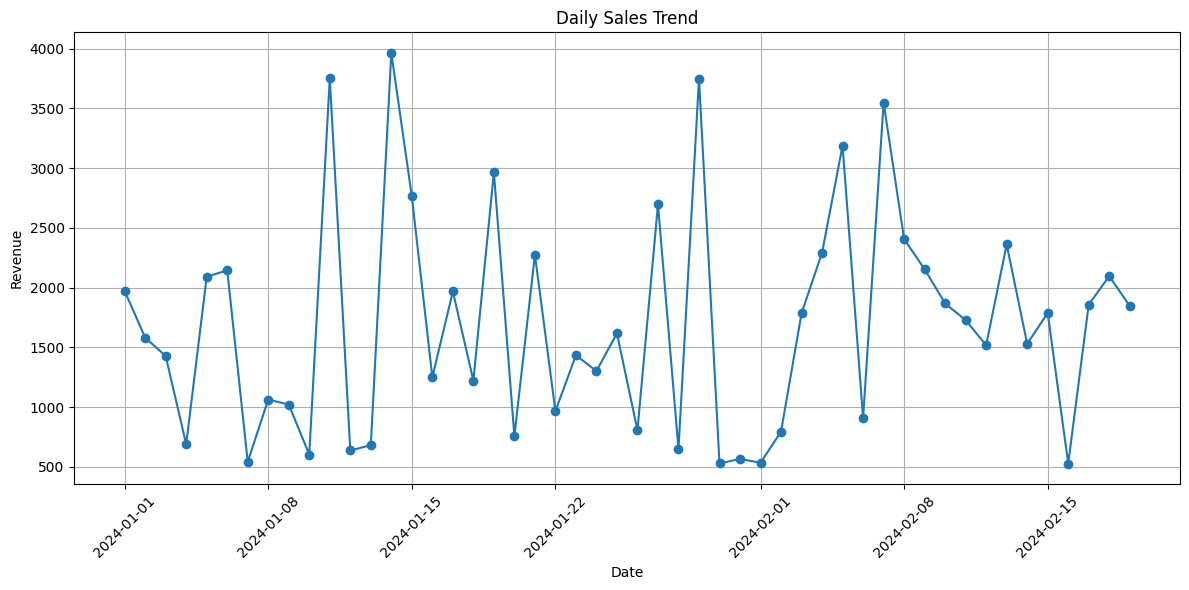

In [43]:
# Highlight peak day
peak_day = daily_sales.idxmax()
peak_value = daily_sales.max()
plt.plot(daily_sales)
plt.scatter(peak_day, peak_value)
plt.text(peak_day, peak_value, 'Peak', fontsize=10)
plt.figure(figsize=(12,6))

plt.plot(daily_sales, marker='o')
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.grid()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
'''cumsum():

Adds revenue day by day
Shows total growth over time

How to Interpret Graph
📈 Steep slope → high growth (good sales period)
➖ Flat line → no sales / low activity
📉 Slower slope → declining performance '''

# Calculate cumulative revenue over time
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

# Daily revenue
daily_sales = df.resample('D', on='Purchase_Date')['Total'].sum()

# Cumulative revenue
cumulative_revenue = daily_sales.cumsum()

print(cumulative_revenue)


Purchase_Date
2024-01-01     1972.000000
2024-01-02     3554.000000
2024-01-03     4982.000000
2024-01-04     5671.000000
2024-01-05     7762.000000
2024-01-06     9907.000000
2024-01-07    10450.000000
2024-01-08    11514.000000
2024-01-09    12536.000000
2024-01-10    13140.000000
2024-01-11    16890.693878
2024-01-12    17528.693878
2024-01-13    18210.693878
2024-01-14    22174.693878
2024-01-15    24937.693878
2024-01-16    26187.693878
2024-01-17    28155.693878
2024-01-18    29377.693878
2024-01-19    32341.693878
2024-01-20    33099.693878
2024-01-21    35375.193878
2024-01-22    36342.193878
2024-01-23    37776.193878
2024-01-24    39078.193878
2024-01-25    40696.193878
2024-01-26    41503.193878
2024-01-27    44199.193878
2024-01-28    44847.193878
2024-01-29    48595.193878
2024-01-30    49124.193878
2024-01-31    49691.193878
2024-02-01    50226.193878
2024-02-02    51021.193878
2024-02-03    52807.193878
2024-02-04    55099.193878
2024-02-05    58287.193878
2024-02-06    

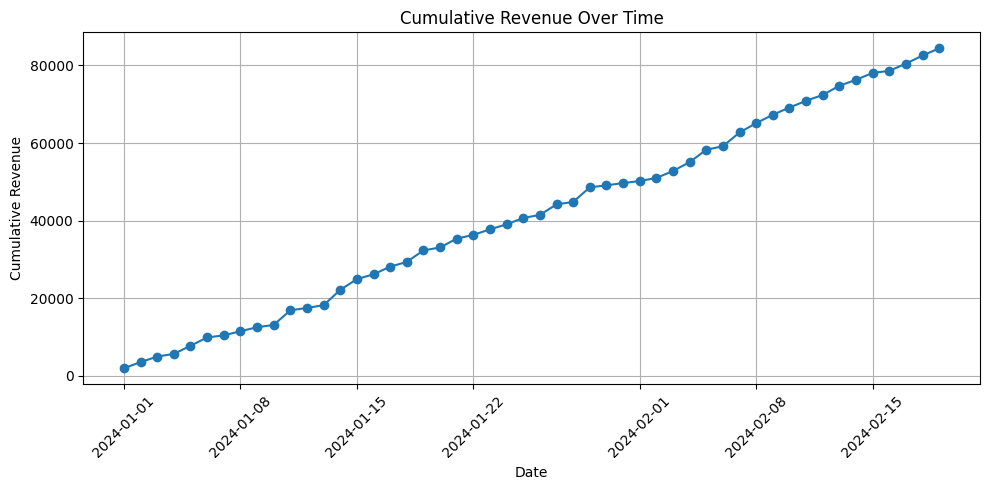

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(cumulative_revenue, marker='o')

plt.title("Cumulative Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Revenue")

plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

plt.show()

In [47]:
''' Rows → City
Columns → Product
Values → Total revenue
Which product sells more in which city
Revenue distribution across locations'''
# Pivot table → City vs Product (sum of Total_Amount)
pivot_table = df.pivot_table(
    values='Total',
    index='City',
    columns='Product',
    aggfunc='sum',
    fill_value=0
)

print(pivot_table)

Product    Headphones  Laptop         Phone  Tablet
City                                               
Bangalore      4025.0  5832.0   4622.000000  1788.0
Chennai        7968.0  5521.0  14599.693878  5845.0
Delhi          5521.0  4243.0   4216.000000  3940.0
Mumbai         1222.0  7798.0   4246.500000  3036.0


In [48]:
#ort by total revenue
pivot_table['Total'] = pivot_table.sum(axis=1)
pivot_table = pivot_table.sort_values(by='Total', ascending=False)

In [49]:
#Find top product per city
pivot_table.idxmax(axis=1)

City
Chennai      Total
Delhi        Total
Mumbai       Total
Bangalore    Total
dtype: object

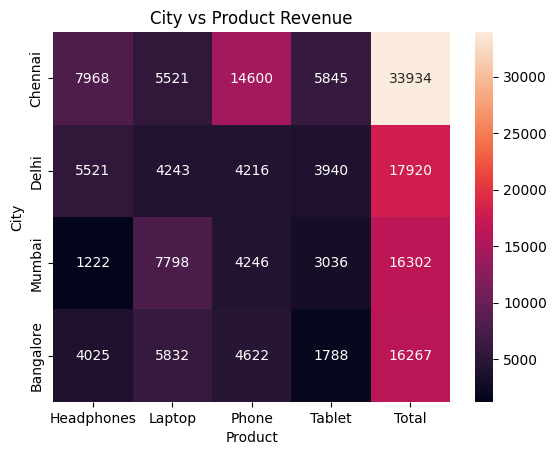

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pivot_table, annot=True, fmt=".0f")
plt.title("City vs Product Revenue")
plt.show()

COMPLETE ML PREPROCESSING PIPELINE

In [ ]:
#Encode Categorical Columns
''' Numerical → Age, Price, Quantity, Total
Categorical → Gender, City, Product, Age_Group, Month
Target → High_Value
Not useful → Customer_ID, Purchase_Date'''
df_model = df.drop(['Customer_ID', 'Purchase_Date'], axis=1)

In [52]:
#Encode Categorical Columns
df_model = pd.get_dummies(
    df_model,
    columns=['Gender', 'City', 'Product', 'Age_Group', 'Month'],
    drop_first=True
)

In [53]:
#Normalize Numerical Features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_model[['Price', 'Total']] = scaler.fit_transform(df_model[['Price', 'Total']])

In [54]:
#Split Features & Target
X = df_model.drop('High_Value', axis=1)
y = df_model['High_Value']

In [55]:
#Correlation with Target
corr = df_model.corr()
corr_target = corr['High_Value'].sort_values(ascending=False)
print(corr_target.head(10))

High_Value         1.000000
Quantity           0.850974
Total              0.805667
Price              0.252867
Gender_Male        0.144174
Product_Phone      0.112272
Age_Group_36-50    0.082106
City_Chennai       0.081264
Month_2            0.081264
City_Mumbai        0.016062
Name: High_Value, dtype: float64


In [56]:
# feature importance
'''Total → high importance
👉 High spending → high-value customer
Price → moderate importance
👉 Expensive items matter
Product_X → specific product influence'''
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))

Total            0.407211
Quantity         0.354874
Price            0.090802
Age              0.054695
Age_Group_50+    0.015395
Gender_Male      0.013152
City_Delhi       0.010423
Month_2          0.010121
Product_Phone    0.008927
City_Chennai     0.007545
dtype: float64
